In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from omegaconf import OmegaConf

def collect_sweep_results(multirun_dir):
    rows = []
    base_path = Path(multirun_dir)
    
    if not base_path.exists():
        print(f"Error: Directory not found: {base_path}")
        return pd.DataFrame()

    config_files = list(base_path.rglob("config.yaml"))
    if not config_files:
        print(f"No config files found in {base_path}")
        return pd.DataFrame()

    target_params = [
        "syn_loc_mean", 
        "syn_loc_std", 
        "exc_syn_weight", 
        "seed",
        "syn_loc_condition",
        "jitter_std"
    ]
    
    # 共通のパラメータ抽出ロジックを外に定義
    def get_val(cfg, k):
        v = cfg.get(k)
        return v if v is not None or 'task' not in cfg else cfg.task.get(k)
    
    # --- スイープパラメータの事前解析 ---
    sweep_summary = {k: set() for k in target_params}
    for cp in config_files:
        temp_cfg = OmegaConf.load(cp)
        for key in target_params:
            val = get_val(temp_cfg, key)
            if val is not None:
                sweep_summary[key].add(val)

    print("=" * 40)
    print(f"Sweep Summary: {base_path.name}")
    for key, values in sweep_summary.items():
        if values:
            sorted_vals = sorted(list(values))
            print(f"  {key:18}: {sorted_vals} (n={len(sorted_vals)})")
    print("-" * 40)
    print(f"Total job directories: {len(config_files)}")
    print("=" * 40)

    # 追跡用：正常に処理できた config_path のセット
    successful_configs = set()

    # --- データ収集 ---
    for config_path in config_files:
        job_dir = config_path.parent.parent if ".hydra" in str(config_path) else config_path.parent
        data_path = job_dir / "data" / "classification_results.npz"
        
        if data_path.exists():
            try:
                cfg = OmegaConf.load(config_path)
                data = np.load(data_path)
                
                row = {k: get_val(cfg, k) for k in target_params}
                
                conf_mat = data['confusion_matrix']
                total = np.sum(conf_mat)
                acc = np.trace(conf_mat) / total if total > 0 else np.nan
                
                row["accuracy"] = acc
                row["job_id"] = job_dir.name
                rows.append(row)
                
                successful_configs.add(config_path) # 成功を記録
                
            except Exception as e:
                print(f"Skipping {job_dir.name} due to error in processing: {e}")

    df = pd.DataFrame(rows)
    
    # --- 欠損（未完了・失敗）ジョブの解析 ---
    missing_configs = set(config_files) - successful_configs
    
    if not df.empty:
        sort_cols = [c for c in target_params if c in df.columns]
        df = df.sort_values(sort_cols).reset_index(drop=True)
        print(f"\nSuccessfully collected {len(df)} / {len(config_files)} results.")
    else:
        print("\nNo results found. Please check data existence.")

    # 欠損がある場合、そのパラメータを表示
    if missing_configs:
        print("\n" + "!" * 15 + " MISSING / FAILED JOBS " + "!" * 15)
        missing_rows = []
        for missing_path in missing_configs:
            try:
                m_cfg = OmegaConf.load(missing_path)
                m_job = missing_path.parent.parent if ".hydra" in str(missing_path) else missing_path.parent
                
                m_row = {k: get_val(m_cfg, k) for k in target_params}
                m_row["job_id"] = m_job.name
                
                # 原因の簡易切り分け
                data_path = m_job / "data" / "classification_results.npz"
                m_row["reason"] = "NPZ file missing (Job crash/Timeout)" if not data_path.exists() else "Load/Parse error"
                
                missing_rows.append(m_row)
            except Exception as e:
                print(f"Could not parse missing config {missing_path}: {e}")
        
        df_missing = pd.DataFrame(missing_rows)
        if not df_missing.empty:
            # 表示順を整理
            m_sort_cols = [c for c in target_params if c in df_missing.columns]
            df_missing = df_missing.sort_values(m_sort_cols).reset_index(drop=True)
            print(df_missing.to_string(index=False))
        print("!" * 53 + "\n")

    return df

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np # ジッター付与に使用

def plot_results(df):
    # 1. データが入っているかチェック
    if df.empty:
        print("Error: DataFrame is empty.")
        return

    # 2. 対象パラメータの存在確認
    target_params = ["syn_loc_mean", "syn_loc_std", "exc_syn_weight", "syn_loc_condition", "jitter_std"]
    available_params = [p for p in target_params if p in df.columns]
    
    if not available_params:
        print(f"Error: Target parameters {target_params} not found.")
        return

    # 3. スイープ（2種類以上の値がある）されているパラメータを特定
    sweep_params = [p for p in available_params if df[p].nunique() > 1]
    
    print(f"Detected sweep parameters: {sweep_params}")

    plt.figure(figsize=(12, 8))
    sns.set_context("talk")
    sns.set_style("whitegrid")

    # --- パターンA: 2変数以上のスイープ (ヒートマップ) ---
    if len(sweep_params) >= 2:
        # ヒートマップは平均値のみを表示（データ点プロットは複雑になるため）
        p1, p2 = sweep_params[0], sweep_params[1]
        print(f"Plotting 2D Sweep Heatmap: {p1} vs {p2}")
        pivot_df = df.groupby([p1, p2])['accuracy'].mean().unstack()
        
        sns.heatmap(pivot_df, annot=True, cmap="viridis", fmt=".3f",
                    cbar_kws={'label': 'Mean Accuracy'})
        plt.title(f"Accuracy Heatmap\n({p1} vs {p2})")

    # --- パターンB: 1変数スイープ (折れ線グラフ + データ点) ---
    elif len(sweep_params) == 1:
        param = sweep_params[0]
        print(f"Plotting 1D Sweep Lineplot with Data Points: {param}")
        
        # 1. まず、生のデータ点をプロット (Scatterplot)
        #   点同士の重なりを避けるため、x軸方向に少しジッター（散らばり）を加える
        df_plot = df.copy()
        
        # パラメータが数値の場合のみジッターを加える
        if np.issubdtype(df_plot[param].dtype, np.number):
            # x軸の範囲に合わせてジッターの幅を調整（最小間隔の10%程度）
            unique_vals = np.sort(df_plot[param].unique())
            if len(unique_vals) > 1:
                min_diff = np.min(np.diff(unique_vals))
                jitter_width = min_diff * 0.1
                # seedに基づいて乱数を固定し、再現性を保ちつつ散らす
                rng = np.random.default_rng(seed=42) 
                df_plot[param] = df_plot[param] + rng.uniform(-jitter_width, jitter_width, len(df_plot))

        sns.scatterplot(data=df_plot, x=param, y="accuracy", 
                        alpha=0.4,     # 透明度を下げて重なりを見やすく
                        color="gray",   # 目立たない色に
                        s=60,          # 点のサイズ
                        label='Raw Data (per seed)',
                        legend=False)   # 凡例はLineplot側のみに統合

        # 2. 平均線とエラーバー（標準偏差）をプロット (Lineplot)
        sns.lineplot(data=df, x=param, y="accuracy", marker='o', 
                    color="tab:blue", # 線の色
                    linewidth=2.5,   # 線を太く
                    markersize=10,   # マーカーを大きく
                    errorbar='sd', err_style="bars", err_kws={'capsize': 5},
                    label='Mean ± SD')

        plt.title(f"Accuracy vs {param}\n(n_seeds={df['seed'].nunique()})")
        plt.legend(loc='best') # 凡例を表示

    # --- パターンC: 全て固定値 (箱ひげ図) ---
    else:
        print("Plotting Distribution for Fixed Parameters")
        sns.boxplot(data=df, y="accuracy", color="skyblue", width=0.4)
        sns.stripplot(data=df, y="accuracy", color="black", alpha=0.5, size=8)
        plt.title("Accuracy Distribution (Fixed Parameters)")

    plt.tight_layout()
    # コマンド履歴が残るよう、ファイル名にスイープ変数をIDとして含めるのが通例
    fig_id = "_".join(sweep_params) if sweep_params else "fixed"
    plt.savefig(f'accuracy_vs_{fig_id}.png', dpi=300)
    plt.show()

Sweep Summary: 17-11-45
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 179 / 180 results.

!!!!!!!!!!!!!!! MISSING / FAILED JOBS !!!!!!!!!!!!!!!
 syn_loc_mean  syn_loc_std  exc_syn_weight  seed syn_loc_condition  jitter_std job_id                               reason
          600           50          0.0005    19   gaussian-apical           3    178 NPZ file missing (Job crash/Timeout)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Lineplot with Data Points: syn_loc_mean


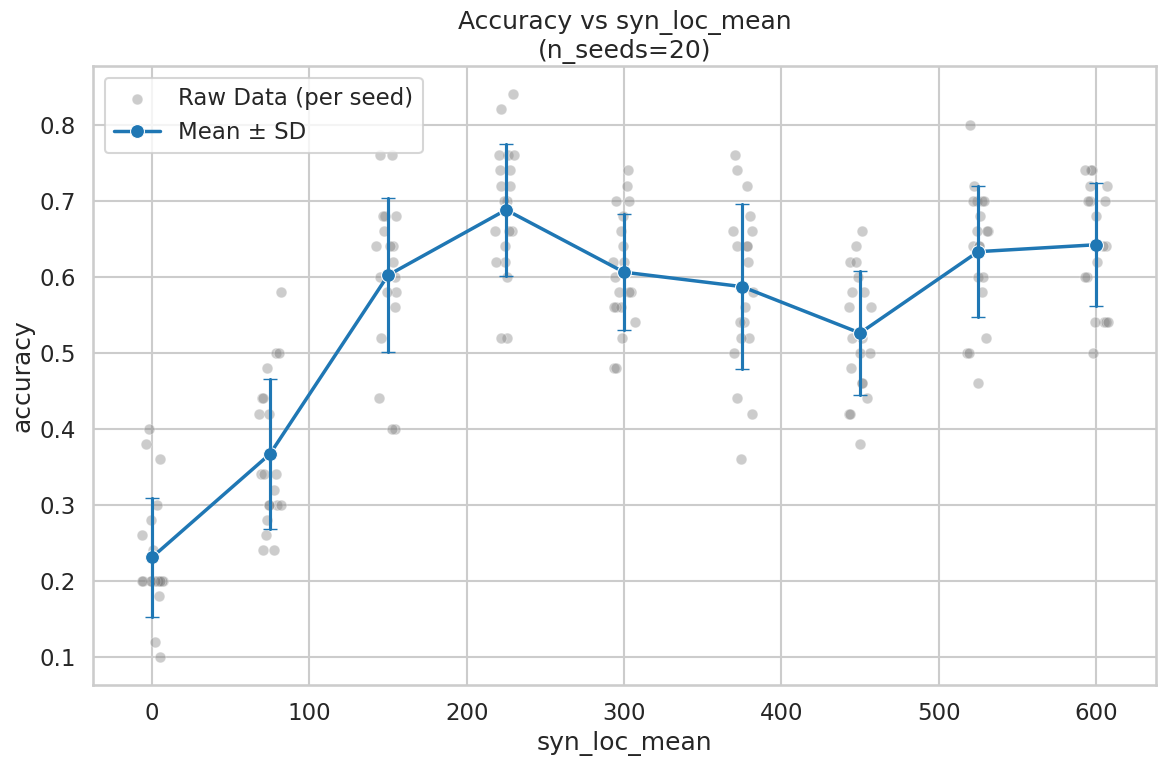

In [6]:
df = collect_sweep_results("../multirun/2026-05-31/17-11-45") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df)

Sweep Summary: 21-58-08
  syn_loc_mean      : [0, 75, 150, 225, 300, 375, 450, 525, 600] (n=9)
  syn_loc_std       : [50] (n=1)
  exc_syn_weight    : [0.0005] (n=1)
  seed              : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] (n=20)
  syn_loc_condition : ['gaussian-apical'] (n=1)
  jitter_std        : [3] (n=1)
----------------------------------------
Total job directories: 180

Successfully collected 178 / 180 results.

!!!!!!!!!!!!!!! MISSING / FAILED JOBS !!!!!!!!!!!!!!!
 syn_loc_mean  syn_loc_std  exc_syn_weight  seed syn_loc_condition  jitter_std job_id                               reason
          600           50          0.0005    19   gaussian-apical           3    178 NPZ file missing (Job crash/Timeout)
          600           50          0.0005    20   gaussian-apical           3    179 NPZ file missing (Job crash/Timeout)
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Detected sweep parameters: ['syn_loc_mean']
Plotting 1D Sweep Li

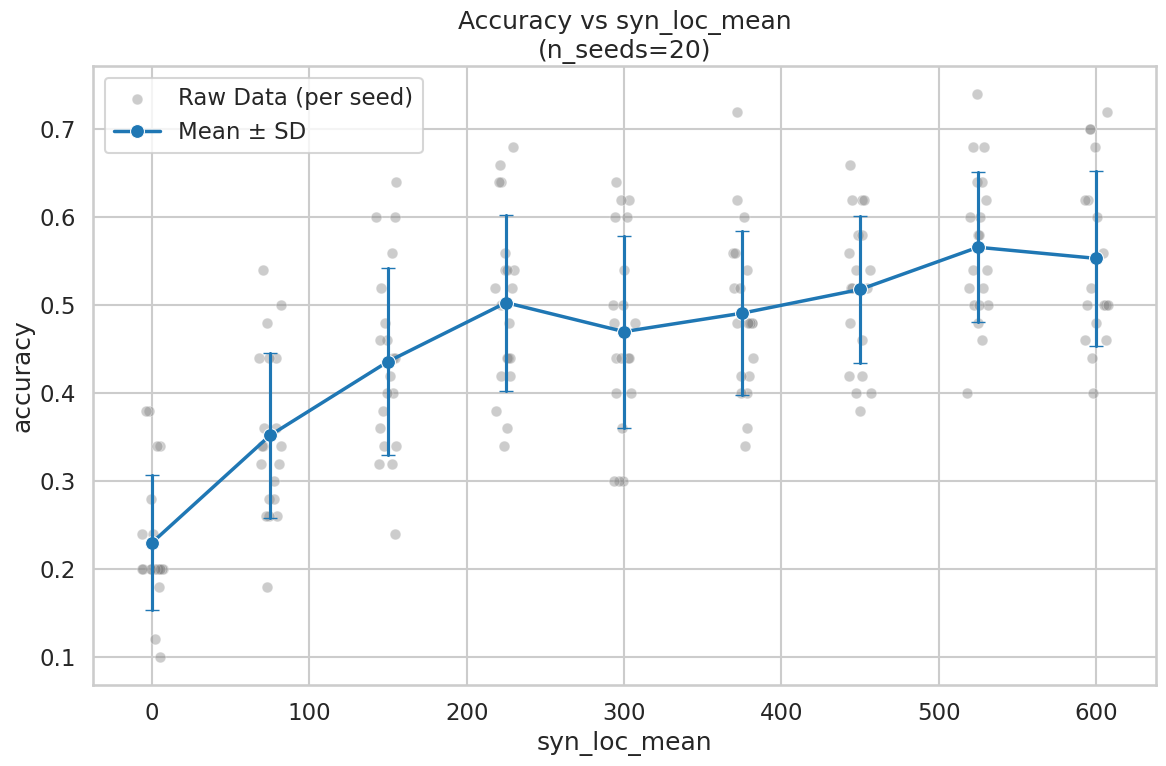

In [7]:
df = collect_sweep_results("../multirun/2026-06-01/21-58-08") # syn_loc_condition = random, sweep param: exc_syn_weight
plot_results(df)